In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [6]:
import pandas as pd

df = pd.read_csv('E:/intern proj/Data-Preprocessing-Feature-Engineering/data/raw_dataset.csv')

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [7]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

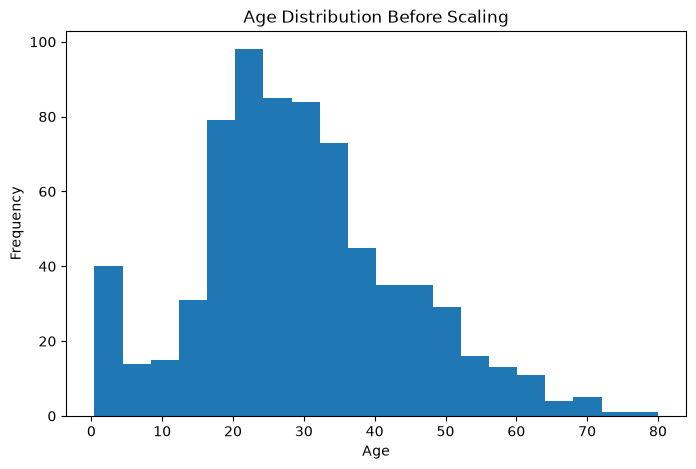

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Age'].dropna(), bins=20)
plt.title("Age Distribution Before Scaling")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [9]:
from sklearn.impute import SimpleImputer

# Numerical columns
num_cols = ['Age', 'Fare']

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical columns
cat_cols = ['Embarked']

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [10]:
df['FamilySize'] = df['SibSp'] + df['Parch']

print(df[['SibSp','Parch','FamilySize']].head())

   SibSp  Parch  FamilySize
0      1      0           1
1      1      0           1
2      0      0           0
3      1      0           1
4      0      0           0


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])

print(df['Sex'].head())

0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64


In [12]:
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    drop_first=True
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,1,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,1,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,1,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,0,False,True


In [13]:
X = df.drop(
    ['Survived', 'Name', 'Ticket', 'Cabin'],
    axis=1
)

y = df['Survived']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (712, 10)
Testing Data Shape: (179, 10)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_features = [
    'Age',
    'Fare',
    'FamilySize'
]

X_train[num_features] = scaler.fit_transform(
    X_train[num_features]
)

X_test[num_features] = scaler.transform(
    X_test[num_features]
)

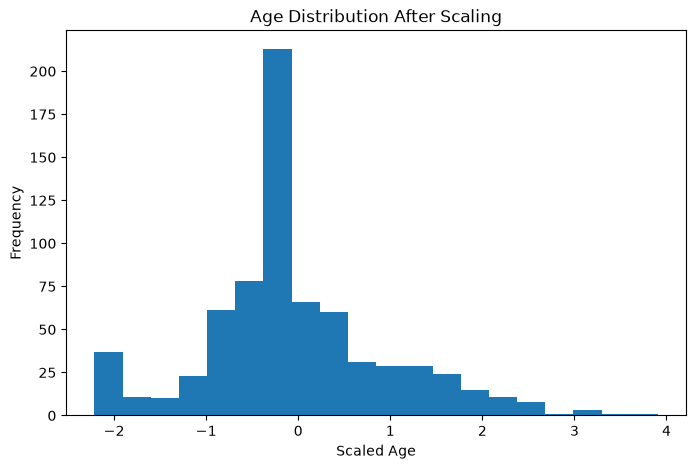

In [16]:
plt.figure(figsize=(8,5))
plt.hist(X_train['Age'], bins=20)
plt.title("Age Distribution After Scaling")
plt.xlabel("Scaled Age")
plt.ylabel("Frequency")
plt.show()

In [17]:
final_df = pd.concat(
    [X_train, y_train],
    axis=1
)

final_df.to_csv(
    r'E:\intern proj\Data-Preprocessing-Feature-Engineering\data\processed_dataset.csv',
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
